# A · Rate Landscape of the Michaelis–Menten–Hill Function

The Hill equation

$$v(S, n) = \frac{k_{\max}\, S^n}{K_m^n + S^n}$$

is the workhorse of enzyme kinetics and the mathematical engine behind
bistability, oscillations, and ultrasensitive switches — all topics in later
modules.

This notebook renders two linked 3-D surfaces:

| Panel | What you see |
|-------|-------------|
| **Left** | The rate $v(S, n)$. For $n = 1$ this is the familiar hyperbolic Michaelis–Menten curve; larger $n$ steepens the rise and sharpens the transition. |
| **Right** | The sensitivity $\partial v / \partial S$ — how rapidly the rate changes per unit of substrate. The peak sharpens and shifts as cooperativity grows. Values above `SENS_CLIP` are saturated so the full colour range is visible over the body of the surface. |

> **Tip:** drag either surface to rotate it — the other panel follows automatically.

In [1]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [5]:
def hill_rate(S, n, k_max=1.0, K_m=1.0):
    """Michaelis-Menten-Hill rate.  n = 1 → standard Michaelis-Menten."""
    return (k_max * S**n) / (K_m**n + S**n)


# ── Parameter grid ────────────────────────────────────────────────────────────
S_values = np.linspace(0.0, 3.0, 120)   # substrate concentration
n_values = np.linspace(0.5, 4.0, 100)   # Hill coefficient
S, N = np.meshgrid(S_values, n_values)  # shape (100, 120)

# Rate landscape — vectorised, no loop
rate = hill_rate(S, N)

# Sensitivity dv/dS — gradient with correct physical spacing
sensitivity = np.gradient(rate, S_values, axis=1)

# ── Display settings ──────────────────────────────────────────────────────────
SENS_CLIP = 1.8       # cap the sensitivity colour scale; values above are saturated
                      # (true max ≈ 5.7 — without clipping colours collapse to the spike tip)

# Colourscales — change either string to taste, e.g. 'Cividis', 'Plasma', 'Hot'
CMAP_RATE = 'Viridis'
CMAP_SENS = 'Plasma'

# Initial camera — larger eye coordinates = viewer further away = more zoomed out
CAMERA_INIT = dict(eye=dict(x=2.0, y=2.0, z=1.4),
                   center=dict(x=0, y=0, z=-0.1))

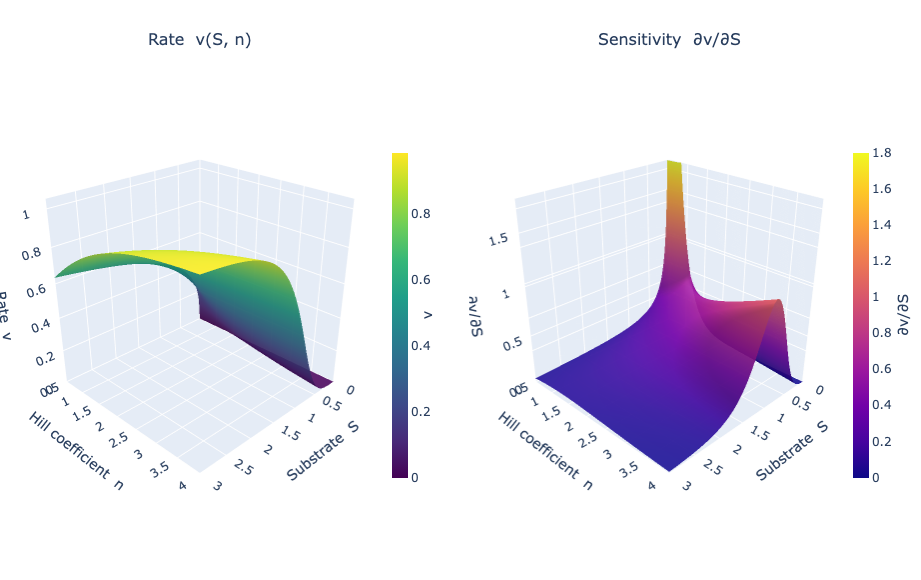

In [6]:
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'surface'}, {'type': 'surface'}]],
    subplot_titles=["Rate  v(S, n)", "Sensitivity  ∂v/∂S"],
    horizontal_spacing=0.08,
)

# ── Left panel: rate ──────────────────────────────────────────────────────────
fig.add_trace(
    go.Surface(
        x=S_values, y=n_values, z=rate,
        colorscale=CMAP_RATE,
        opacity=0.92,
        hoverinfo='skip',
        colorbar=dict(
            title=dict(text="v", side="right"),
            x=0.44, len=0.65, thickness=16, y=0.5, yanchor='middle',
        ),
    ),
    row=1, col=1,
)

# ── Right panel: sensitivity ──────────────────────────────────────────────────
fig.add_trace(
    go.Surface(
        x=S_values, y=n_values, z=sensitivity,
        colorscale=CMAP_SENS,
        opacity=0.92,
        hoverinfo='skip',
        cmin=0, cmax=SENS_CLIP,      # saturate above SENS_CLIP for colour contrast
        colorbar=dict(
            title=dict(text="∂v/∂S", side="right"),
            x=0.97, len=0.65, thickness=16, y=0.5, yanchor='middle',
        ),
    ),
    row=1, col=2,
)

# ── Axis labels, ranges, initial camera ──────────────────────────────────────
scene_common = dict(
    xaxis=dict(title="Substrate  S",        range=[0, 3]),
    yaxis=dict(title="Hill coefficient  n", range=[0.5, 4]),
    camera=CAMERA_INIT,
    aspectmode='cube',
)

fig.update_layout(
    scene  = dict(**scene_common,
                  zaxis=dict(title="Rate  v",       range=[0, 1.05])),
    scene2 = dict(**scene_common,
                  zaxis=dict(title="∂v/∂S",          range=[0, SENS_CLIP])),
    width=1060, height=580,
    margin=dict(l=0, r=0, t=50, b=0),
    paper_bgcolor='white',
)

fig

## Linked cameras

Run the cell below to convert the figure to an interactive `FigureWidget`.
After that, **rotating or zooming** either panel updates the other automatically.

*Note: camera sync requires the Python kernel to be running — it is not
preserved in exported HTML.*

In [4]:
fw = go.FigureWidget(fig)

# Guard flag — prevents the two callbacks from triggering each other
_syncing = [False]

def _sync_1_to_2(scene_obj, camera):
    """LEFT panel moved → copy camera to RIGHT."""
    if not _syncing[0]:
        _syncing[0] = True
        fw.layout.scene2.camera = camera   # direct assignment (no batch_update)
        _syncing[0] = False                # reset after Python callback completes

def _sync_2_to_1(scene_obj, camera):
    """RIGHT panel moved → copy camera to LEFT."""
    if not _syncing[0]:
        _syncing[0] = True
        fw.layout.scene.camera = camera
        _syncing[0] = False

fw.layout.scene.on_change(_sync_1_to_2,  'camera')
fw.layout.scene2.on_change(_sync_2_to_1, 'camera')

fw

FigureWidget({
    'data': [{'colorbar': {'len': 0.65,
                           'thickness': 16,
                           'title': {'side': 'right', 'text': 'v'},
                           'x': 0.44,
                           'y': 0.5,
                           'yanchor': 'middle'},
              'colorscale': [[0.0, '#440154'], [0.1111111111111111, '#482878'],
                             [0.2222222222222222, '#3e4989'], [0.3333333333333333,
                             '#31688e'], [0.4444444444444444, '#26828e'],
                             [0.5555555555555556, '#1f9e89'], [0.6666666666666666,
                             '#35b779'], [0.7777777777777778, '#6ece58'],
                             [0.8888888888888888, '#b5de2b'], [1.0, '#fde725']],
              'hoverinfo': 'skip',
              'opacity': 0.92,
              'scene': 'scene',
              'type': 'surface',
              'uid': '9158dc9f-fe4f-46ae-98b3-51676651f038',
              'x': {'bdata': ('AAAAAAAAAAA

## Export

Saves a standalone HTML; both panels are rotatable in any browser but camera
sync is not active without the kernel.

In [ ]:
# Uncomment to export
# fig.write_html("MM_Hill_surfaces.html")